In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


# House Prices EDA

## 1.分析の目的
House Pricesでは、特徴量が多く、また数値列やカテゴリ列に分類すること、欠損値の扱い、外れ値へのアプローチを考えることが重要であるため分析を行っていく

## 2.データの読み込み

In [2]:
train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")


## 3.データ全体の確認 
trainデータについて
>1460行、81列

In [3]:
train.shape
train.head()
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


testデータについて
>1459行、80列。trainデータより1列少ないのは、目的変数SalePriceが欠けているからである。

In [4]:
test.shape

(1459, 80)

## 4.目的変数SalePriceの分析
* 最小値34900、最大値755000であり、右に伸びたデータである。
* 対数変換を行い、データを扱いやすくしたものを図示する。

In [5]:
train.SalePrice.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

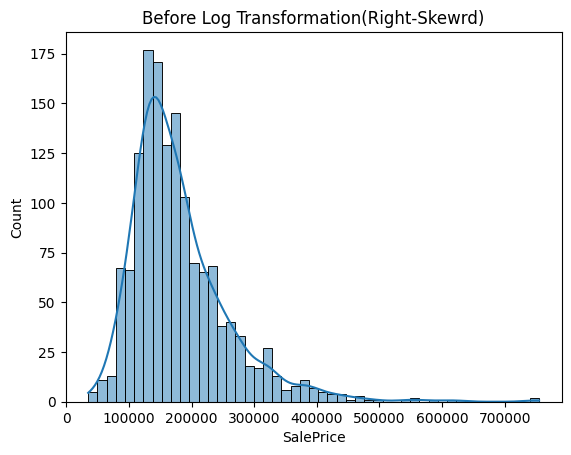

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train["SalePrice"], kde=True)
plt.title("Before Log Transformation(Right-Skewrd)")
plt.show()

対数変換後が以下。"SalePrice"は右に歪んだ分布であるため対数変換を行う。これによるメリットとして
* 正規分布に近づけることが出来る
* 外れ値の影響を弱める
* 一部のモデルにおいて学習しやすくなる

  などがあげられる。

/tmp/ipykernel_16/3355980449.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  train.LogSalePrice = np.log1p(train.SalePrice)


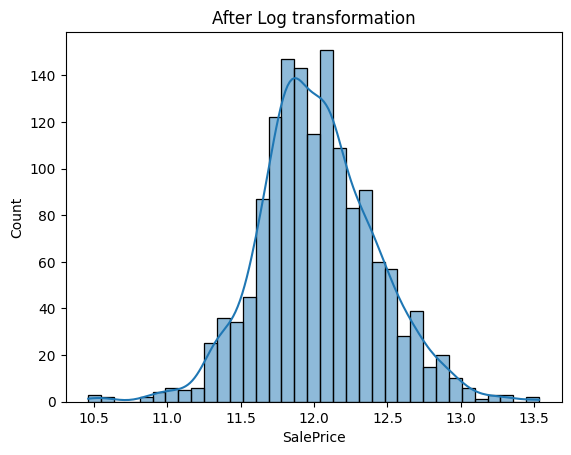

In [7]:
import numpy as np 

train.LogSalePrice = np.log1p(train.SalePrice)

sns.histplot(train.LogSalePrice, kde=True)
plt.title("After Log transformation")
plt.show()

## 5.特徴量の種類の整理
1. まず全特徴量を表示
2. 特徴量の属性として、数値ではあるがカテゴリとしてみた方が良いもの、カテゴリだが数値としてみた方が良いものを分類(値に大小、順序があるか）
3. 最終的に、数値列(numeric_cols)、カテゴリ列(normal_cat_cols)、順序ありのカテゴリ列(ordinal_cat_cols)の3つの大分類に分けていく

In [8]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [9]:
#1.ID列とSalePrice(目的変数)列の除去
id_col = "Id"
target_col = "SalePrice"

#2.数値列ではあるがカテゴリ列として扱う列
numeric_to_category = [
    "MSSubClass", #住宅の種類番号(Idのような識別番号)のため
    "MoSold" #月を表す数値のためそれ自体に大小関係はないため
]

train[numeric_to_category] = (
    train[numeric_to_category].astype("category")
)

test[numeric_to_category] = (
    test[numeric_to_category].astype("category")
)

#3.説明変数を取り出す
X = train.drop(columns=[id_col,target_col])

#4.数値列
num_cols = (
    X.select_dtypes(include="number")
    .columns
    .tolist()
)

#5.カテゴリ列
cat_cols = (
    X.select_dtypes(include=["object","category"])
    .columns
    .tolist()
)


In [10]:
#カテゴリ列ではあるが、順序を持つもの(値の大小を含むもの)を分類
ordinal_cat_cols = [
    "ExterQual", #外壁材の品質(Excellent→Poorの順)
    "ExterCond", #外壁材の状態(良い→悪いの順)
    "BsmtQual", #地下室の仕上がり(高→低の順）
    "BsmtCond", #地下室の状態(良い→悪いの順)
    "BsmtExposure", #地下室の採光、外への露出度(Walkout→None)
    "BsmtFinType1", #地下室の主要な仕上げタイプ(高→低)
    "BsmtFinType2", #地下室の追加仕上げタイプ(高→低)
    "HeatingQC", #暖房設備の品質
    "KitchenQual", #キッチンの品質
    "Functional", #家の機能性
    "FireplaceQu", #暖炉の品質
    "GarageFinish", #ガレージの内装仕上げ
    "GarageQual", #ガレージの品質
    "GarageCond", #ガレージの状態
    "PavedDrive", #舗装された車道の有無
    "PoolQC" #プールの品質
]

#通常のカテゴリ列
normal_cat_cols = [
    col for col in cat_cols if col not in ordinal_cat_cols
]

In [11]:
#最終結果
print("数値列数:", len(num_cols))
print("通常のカテゴリ列数:", len(normal_cat_cols))
print(("順序ありカテゴリ列数:"), len(ordinal_cat_cols))

print("\n数値列")
print(num_cols)

print("\n通常カテゴリ列")
print(normal_cat_cols)

print("\n順序ありカテゴリ列")
print(ordinal_cat_cols)

数値列数: 34
通常のカテゴリ列数: 29
順序ありカテゴリ列数: 16

数値列
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold']

通常カテゴリ列
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'Fence', 'MiscFeature', 'MoSold', 'SaleType', 'SaleCondition']

順序ありカテゴリ列
['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType

合計で79列なので、IdとSalePriceを除いたすべての列が重複せずに分類されていることが確認できる。

## 6.欠損値の分析
1. 欠損がある列を、欠損の合計、欠損率、データ型、特徴量の種類で表示
2. 図に表す

In [12]:
#欠損値をまとめたDF。欠損値の合計、割合、データ型を記載
missing_summary = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_rate": X.isna().mean() * 100,
    "dtype":X.dtypes.astype(str)
})

#特徴量のグループ分け
feature_groups = {
    "数値列":num_cols,
    "通常カテゴリ列":normal_cat_cols,
    "順序カテゴリ列":ordinal_cat_cols
}

#各列が数値列、通常カテゴリ列、順序カテゴリ列のどれであるかわかる辞書
feature_type_map = {
    col:group
    for group, cols in feature_groups.items()
    for col in cols
}

#欠損値をまとめたDFにどの種類の特徴量なのかがわかる列を追加
missing_summary["feature_type"] = missing_summary.index.map(feature_type_map)

#欠損がある列+欠損率で並び替え
missing_summary = (
    missing_summary
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
)

missing_summary

,missing_count,missing_rate,dtype,feature_type
PoolQC,1453,99.520548,object,順序カテゴリ列
MiscFeature,1406,96.301370,object,通常カテゴリ列
Alley,1369,93.767123,object,通常カテゴリ列
Fence,1179,80.753425,object,通常カテゴリ列
MasVnrType,872,59.726027,object,通常カテゴリ列
FireplaceQu,690,47.260274,object,順序カテゴリ列
LotFrontage,259,17.739726,float64,数値列
GarageType,81,5.547945,object,通常カテゴリ列
GarageYrBlt,81,5.547945,float64,数値列
GarageFinish,81,5.547945,object,順序カテゴリ列


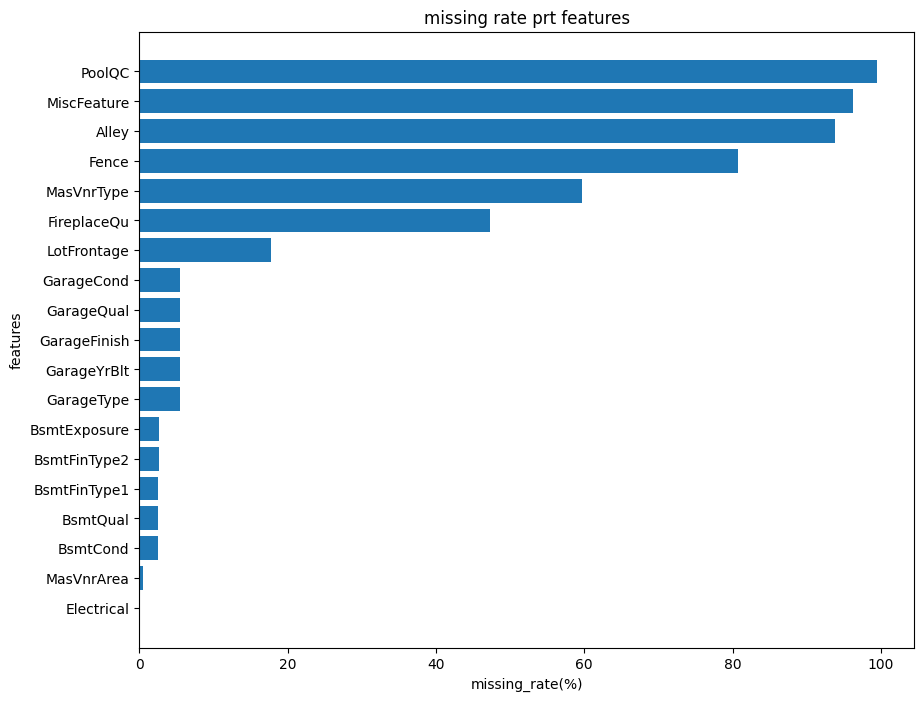

In [13]:
import matplotlib.pyplot

as_True = missing_summary.sort_values("missing_rate", ascending=True)

plt.figure(figsize=(10,8))

plt.barh(
    as_True.index,
    as_True.missing_rate
)

plt.xlabel("missing_rate(%)")
plt.ylabel("features")
plt.title("missing rate prt features")

plt.show()

欠損に、大きく3つの種類があり
>| 欠損の種類 | 意味             | 処理候補               |
| ----- | -------------- | ------------------ |
| 構造的欠損 | 設備そのものがない      | `NoFeature`などのカテゴリ |
| 本当の欠損 | 値が記録されていない     | 中央値・最頻値など          |
| 判定が必要 | 設備なしと本当の欠損が混ざる | 関連列と照合             |

数値列、カテゴリ列のそれぞれについて、欠損のある特徴量の取り扱いを見ていく

## 7.数値特徴量の分析
1. 先ほどみた欠損の多いLotFrontageは、とりあえず最初段階では消す
2. SalePriceの時と同様に、対数変換を行うために、まずは対数変換する対象列を決める

対数変換を行う列として、次の条件を満たすものを考える。
> 値の種類が15種類より多い(1~10の段階評価の物を除くため)

>年を表す列ではない(年は”数量”ではなく、”位置”なのでlogを使うと意味合いが壊れる

>最小値が0以上(-の物は対数変換できない)

>歪度が0.75より大きい(歪みが大きいものに限る)

In [14]:
#欠損が多いものを削除
#num_cols = num_cols.remove("LotFrontage") remveの戻り値はNoneなのでエラー
num_cols = [col for col in num_cols 
           if col != "LotFrontage"]

#year関連の特徴量と、それ以外の数値列を分ける
year_cols = [
    "YearBuilt",
    "YearRemodAdd",
    "GarageYrBlt",
    "YrSold"
]

#分析用のDFを作る
num_eda = train[num_cols + ["SalePrice"]].copy()

#対数変換対象の数値列を選んでいく
#連続数値列を作る
continuous_num_cols = [
    col for col in num_cols
    if col in num_eda.columns
    and num_eda[col].nunique(dropna=True) > 15 #値の種類が15以上あれば連続数値列とみなす
    #and num_eda[col].min() >= 0 特にマイナスの値の列が無いので削除
    and col not in year_cols
]

#次に離散数値列の特徴量をまとめる。後で使う
discrete_num_cols = [
    col for col in num_cols
    if num_eda[col].nunique(dropna=True)<=15 #10段階評価など
    and col not in year_cols
]


#対数変換の対象列の歪度を計算する
skewness = (
    num_eda[continuous_num_cols]
    .skew()
    .sort_values(ascending=False)
)

skewness_df = skewness.to_frame(name="skewness")
skewness_df

,skewness
MiscVal,24.476794
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341
BsmtFinSF2,4.255261
ScreenPorch,4.122214
EnclosedPorch,3.089872
MasVnrArea,2.669084
OpenPorchSF,2.364342
BsmtFinSF1,1.685503


In [15]:
#右側への歪みが大きいものを対数変換するため0.75以上のもの
skewed_cols = skewness[skewness>0.75].index.to_list()
print("対数変換する列数:", len(skewed_cols))
print(skewed_cols)

対数変換する列数: 16
['MiscVal', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'BsmtFinSF2', 'ScreenPorch', 'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF', 'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'BsmtUnfSF', '2ndFlrSF']


詳しい対数変換は、後の特徴量エンジニアリングで進めていく。

## 8.カテゴリ特徴量の分析
1. カテゴリ列は、先ほどの”通常カテゴリ列”、”順序カテゴリ列”の2つに分類
2. 欠損列の意味合いについて考える
   >①欠損が「設備無し」を表す列
   >
   >②本当に値が不明な列
   >
   >③欠損率が高く、情報量も少ない列
   >
3. それぞれの欠損値の取り扱いは、次の前処理の段階で進めていく
4. 

In [16]:
#①欠損が「設備無し」を表す列
#欠損を”None”で埋める候補
absence_cat_cols = [
    "Alley", #家の敷地に接する路地の種類（舗装 / 砂利）。NA は「路地なし」
    "BsmtQual", #地下室の仕上がり品質（Excellent → Poor）。NA は「地下室なし
    "BsmtCond", #地下室の状態（良好 → 悪い）。NA は「地下室なし」
    "BsmtExposure", #地下室の外への露出度（Walkout → None）。NA は「地下室なし」
    "BsmtFinType1", #地下室の主要仕上げタイプ（高品質 → 未仕上げ）。NA は「地下室なし」
    "BsmtFinType2", #地下室の追加仕上げタイプ。NA は「地下室なし」
    "FireplaceQu", #暖炉の品質（Excellent → Poor）。NA は「暖炉なし」
    "GarageType", #ガレージの種類（Attached / Detached など）。NA は「ガレージなし」
    "GarageFinish", #ガレージ内装の仕上げ（Finished → Unfinished）。NA は「ガレージなし」
    "GarageQual", #ガレージの品質（Excellent → Poor）。NA は「ガレージなし」
    "GarageCond", #ガレージの状態（良好 → 悪い）。NA は「ガレージなし」
    "PoolQC", #プールの品質（Excellent → Poor）。NA は「プールなし
    "Fence", #フェンスの種類（木製 / 金属など）。NA は「フェンスなし」
    "MiscFeature" #その他の特別設備（棚、テニスコートなど）。NA は「特別設備なし」
]

#②本当に値が不明な列
#このような列は、最頻値で補完する候補
unknown_cat_cols = [
    col for col in cat_cols
    if train[col].isna().any()
    and col not in absence_cat_cols
]

#③欠損率が非常に高く、情報量も少ない列
#削除候補
drop_candidata = [
    "Alley", #家の敷地が接している「路地（未舗装の裏道）」の種類。
    "PoolQC", #プールの品質評価（Excellent → Poor）。
    "Frence", #フェンスの種類（木製・金属など）。
    "MiscFeature" #その他の特殊設備（テニスコート、シェッドなど）。
]

len(absence_cat_cols + unknown_cat_cols + drop_candidata)

20

## 9.SalePriceとの関係
ここまでの特徴量まとめ
* ”LotFrontage”は欠損が多いため、数値列から削除
* ”MSSubClass", "MoSold"は、値が数値ではあるが、値の意味合いから判断して、カテゴリ列に含める
* 数値列
  >連続数値列:continuous_num_cols
  >
  >離散数値列:discrete_num_cols
  >
  >年の列:year_cols
  >
* カテゴリ列
  >通常カテゴリ列:normal_cat_cols
  >
  >順序カテゴリ列:ordinal_cat_cols

In [17]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

target = "SalePrice"

/tmp/ipykernel_16/4008880190.py:44: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/4008880190.py:44: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/4008880190.py:44: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/4008880190.py:44: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/4008880190.py:44: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/4008880190.py:44: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/4008880190.py:44: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu 

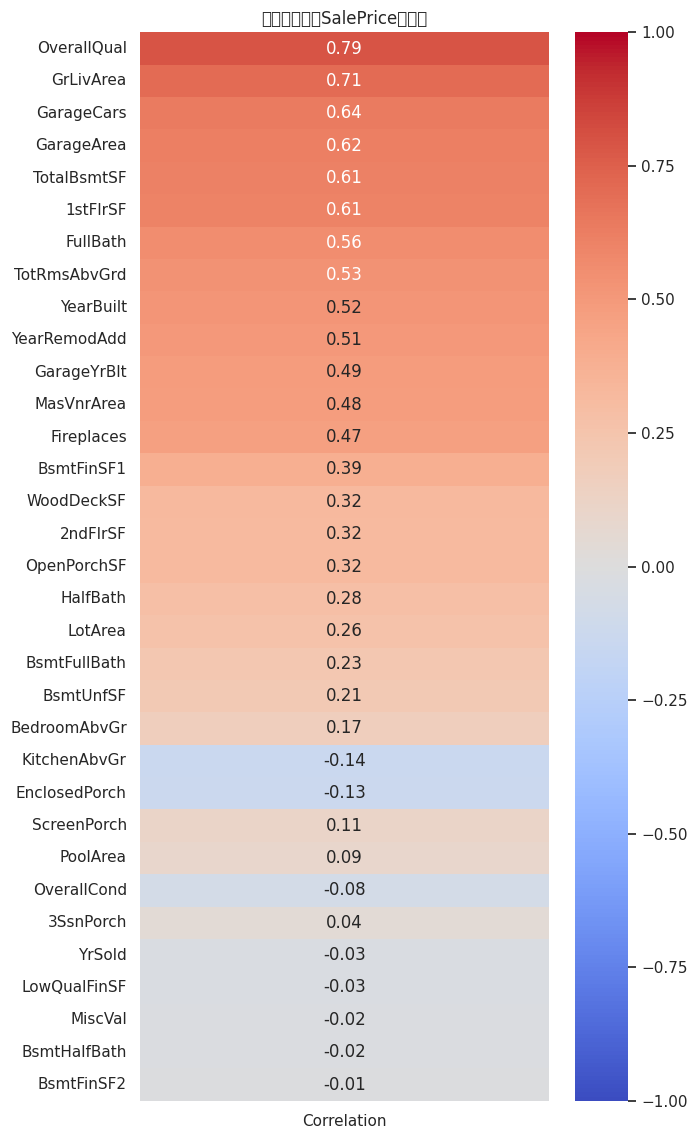

In [18]:
# 数値列を1つにまとめる
numeric_relation_cols = list(dict.fromkeys(
    continuous_num_cols
    + discrete_num_cols
    + year_cols
))

# trainに存在する列だけ残す
numeric_relation_cols = [
    col for col in numeric_relation_cols
    if col in train.columns
]

# SalePriceとの相関係数を計算
saleprice_corr = (
    train[numeric_relation_cols + [target]]
    .corr(method="pearson")[target]
    .drop(target)
)

# 相関の絶対値が大きい順に並べる
saleprice_corr = saleprice_corr.reindex(
    saleprice_corr.abs()
    .sort_values(ascending=False)
    .index
)

# ヒートマップ
plt.figure(
    figsize=(7, max(6, len(saleprice_corr) * 0.35))
)

sns.heatmap(
    saleprice_corr.to_frame(name="Correlation"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("数値特徴量とSalePriceの相関")
plt.tight_layout()
plt.show()

## 10.特徴量同士の関係
* 特徴量の中には、同じ要素を違う側面から見たものがある
  >例;ガレージ関連、地下室関連、居住面積や環境関連など。
* 同じグループは互いに正の相関関係にあると考えられる。
* つまり、欠損については同じグループであれば同じような正の相関値で埋めることが妥当なのではないか、と予測される。

## 11.外れ値の確認

## 12.分析結果と次に試すこと
* 目的変数SalePriceは値の分布が右に歪んでいるため、対数変換を行ってからモデル勉強に適用した方が、モデルが学習しやすくなるので、対数変換を使ってみたい。
* "MSSubClass","MoSold"については、数値列ではあるが、値の意味合いとしてはカテゴリと同じなので、カテゴリ列として扱う。
* カテゴリ列は、「通常カテゴリ列」「順序カテゴリ列」の2つに分類する
* 数値列の歪度の大きい”skewed_cols”については、対数変換を行った方が良いか確認
* 欠損値の取り扱い
  >①数値列については、欠損率が高い"LotFrontage"は削除するか、平均値で埋める
  >
  >②カテゴリ列の特徴によって分ける。欠損が「設備なし」を表す列についてはNoneで埋め(absence_cat_cols)、本当に値が不明な列については最頻値で埋め(unknown_cat_cols)、欠損が非常に高く情報量も少ない列については列ごと消すかNoneで埋める(drop_candidates)
* 